# Model Analysis — Logistic Regression

This notebook develops and compares logistic regression models to predict customer response to a monthly food basket subscription campaign for a retail food company. Building on the EDA, which identified behavioural variables, particularly past campaign acceptance and recency, as the strongest predictors of response, the modelling strategy follows a structured diagnostic logic:

1. A **Full Model** trained on all engineered features to identify which predictors survive penalisation.
2. A **Behavioural Model** focusing on engagement and purchase history.
3. A **Demographic Model** focusing on customer profile and household composition.

Comparing these three models allows us to assess whether campaign response is better explained by *who the customer is* or *how the customer behaves*, and to select the most actionable model for deployment.

## 0. Setup & Data Loading

In [201]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay, precision_recall_curve
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

import warnings
warnings.filterwarnings('ignore')

# Threshold Tuning
def find_best_threshold_oof(pipeline, X_train, y_train, cv=5):
    oof_probs = cross_val_predict(
        pipeline, X_train, y_train, cv=cv, method="predict_proba"
    )[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(y_train, oof_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print(f"Optimal threshold (F1): {best_threshold:.4f}")
    print(f"Best OOF F1:            {best_f1:.4f}")

    return best_threshold

In [202]:
# Data loading
df = pd.read_csv('../data/marketing_campaign_clean.csv')

# Data overview
print(f"Dataset shape: {df.shape}")
print(f"\nClass balance:")
print(df['Response'].value_counts(normalize=True).round(3))
df.columns

Dataset shape: (2236, 30)

Class balance:
Response
0    0.851
1    0.149
Name: proportion, dtype: float64


Index(['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Income_missing', 'Customer_Tenure', 'Age',
       'Total_Spending', 'Total_Purchases', 'Total_Accepted_Campaigns',
       'Response'],
      dtype='object')

## 1. Feature Selection

The clean dataset already includes the engineered features from the EDA notebook
(`Total_Spending`, `Total_Purchases`, `Total_Accepted_Campaigns`, `Customer_Tenure`, `Age`).

The original columns (individual spend categories and individual campaign dummies) are
dropped here, as they have been combined into the aggregated features. `Income_missing` and
`Complain` are also dropped.

To enable clean model comparisons, three non-overlapping feature sets are constructed upfront and in the following section.

In [ ]:
# Create copy of the dataframe for modeling
df_model = df.copy()

# Drop columns that won't be used in the model
cols_to_drop = [
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
    'Income_missing', 'Complain'
]

df_model = df_model.drop(columns=cols_to_drop)


# Define features and target
target = 'Response'

## Full Model
numerical_features_full = [
    'Age', 'Income', 'Recency', 'Customer_Tenure',
    'Total_Spending', 'Total_Purchases', 'Total_Accepted_Campaigns',
    'NumDealsPurchases', 'NumWebVisitsMonth',
    'Kidhome', 'Teenhome'
]
categorical_features_full = ['Education', 'Marital_Status']

## Behavioural Model
numerical_features_behav = [
    'Recency', 'Total_Spending', 'Total_Purchases',
    'Total_Accepted_Campaigns', 'NumDealsPurchases', 'NumWebVisitsMonth'
]
categorical_features_behav = [] 

# Demographic Model
numerical_features_demo = [
    'Age', 'Income', 'Customer_Tenure',
    'Kidhome', 'Teenhome'
]
categorical_features_demo = ['Education', 'Marital_Status']


print(f"Full model: {len(numerical_features_full)} numerical + {len(categorical_features_full)} categorical")
print(f"Behavioural: {len(numerical_features_behav)} numerical + {len(categorical_features_behav)} categorical")
print(f"Demographic: {len(numerical_features_demo)} numerical + {len(categorical_features_demo)} categorical")

Full model: 11 numerical + 2 categorical
Behavioural: 6 numerical + 0 categorical
Demographic: 5 numerical + 2 categorical


## 2. Train/Test Split

A single stratified split is performed on the full index **before** any model is fitted.
All three models then reuse the same training and test observations.

The split uses stratify=y to preserve the 85/15 class ratio in both partitions, ensuring the test set is representative of the overall population. Class imbalance is addressed at the modeling stage through threshold tuning (Section 6.3).

In [204]:
X_all = df_model[numerical_features_full + categorical_features_full]
y = df_model[target]

# Single stratified split (if there were three separate splits, there could potentially be three different test sets)
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Slice each feature set from the shared split
X_train_full  = X_train_all[numerical_features_full + categorical_features_full]
X_test_full   = X_test_all[numerical_features_full + categorical_features_full]

X_train_behav = X_train_all[numerical_features_behav]
X_test_behav  = X_test_all[numerical_features_behav]

X_train_demo  = X_train_all[numerical_features_demo + categorical_features_demo]
X_test_demo   = X_test_all[numerical_features_demo + categorical_features_demo]

print(f"Train size: {len(y_train):,}  (positives: {y_train.sum()})")
print(f"Test size: {len(y_test):,}   (positives: {y_test.sum()})")

Train size: 1,788  (positives: 267)
Test size: 448   (positives: 67)


## 3. Full Model with Elastic Net Regularization 

The full model employs **Elastic Net** regularisation, which combines L1 and L2 penalties in a weighted sum governed by l1_ratio. 
This decision is driven by the feature set's two competing characteristics: 
- The EDA correlation heatmap revealed significant *multicollinearity* (particularly between Total_Spending and Income, with Total_Purchases closely tracking both), which L2 handles better than L1 alone. 
- At the same time, numerous features revealed *weak or near-zero relationships* with Response in the EDA (Age, NumDealsPurchases, NumWebVisitsMonth), indicating that some degree of automated feature selection is required, which L1 does but L2 does not.

Elastic Net incorporates both: the L2 stabilises coefficient estimates under multicollinearity, while the L1 retains the ability to zero out uninformative predictors.

### 3.1. Preprocessing Pipeline & Full Logistic Regression Model

In [205]:
## Preprocessing Pipeline (Full Model)
preprocessor_full = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_full),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features_full)
    ]
)

## Full Logistic Regression (L1)
full_model = Pipeline(steps=[
    ('preprocessor', preprocessor_full),
    ('classifier', LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        l1_ratio=0.5,
        C=1.0,
        max_iter=2000,
        random_state=42
    ))
])

full_model.fit(X_train_full, y_train)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Income', 'Recency',
                                                   'Customer_Tenure',
                                                   'Total_Spending',
                                                   'Total_Purchases',
                                                   'Total_Accepted_Campaigns',
                                                   'NumDealsPurchases',
                                                   'NumWebVisitsMonth',
                                                   'Kidhome', 'Teenhome']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Education',
                                                   'Marital_Status'])])),
                ('classifier',
                 LogisticRegression(l1_ratio=0.5, max_iter=2000,
                                    penalty='elasticnet', random_state=42,
                                    solver='saga'))])

In [206]:
# l1_ratio Tuning
param_grid = {'classifier__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}

search = GridSearchCV(full_model, param_grid, cv=5, scoring='roc_auc')
search.fit(X_train_full, y_train)

print(f"Best l1_ratio : {search.best_params_['classifier__l1_ratio']}")
print(f"Best CV AUC   : {search.best_score_:.4f}")

full_model = search.best_estimator_

Best l1_ratio : 0.3
Best CV AUC   : 0.8866


### 3.2 Threshold Tuning

By default, scikit-learn classifiers predict a positive class whenever the predicted probability exceeds 0.5, which is rarely optimal under class imbalance. 

In a marketing campaign context, the choice of threshold has direct business consequences: too low and the company wastes resources contacting customers who will not convert, and too high and genuine prospects are missed entirely. 

To find the cutoff that best balances these two costs, we evaluate the F1 score across all possible thresholds using out-of-fold cross-validation probabilities on the training set, ensuring no test data influences the selection. 

**F1** is the appropriate criteria here as it only scores high when both precision and recall are strong, rewarding a threshold that maximises correctly identified responders without generating a disproportionate number of wasted contacts. The resulting optimal threshold replaces the default 0.5 and is applied to the test set for final evaluation.

In [207]:
threshold_full = find_best_threshold_oof(full_model, X_train_full, y_train)

Optimal threshold (F1): 0.3262
Best OOF F1:            0.5741


### 3.3. Model Evaluation

In [208]:
## Predictions
y_prob_full = full_model.predict_proba(X_test_full)[:,1]
y_pred_full = (y_prob_full >= threshold_full).astype(int)

## Metrics
accuracy_full = accuracy_score(y_test, y_pred_full)
precision_full = precision_score(y_test, y_pred_full)
recall_full = recall_score(y_test, y_pred_full)
f1_full = f1_score(y_test, y_pred_full)
auc_full = roc_auc_score(y_test, y_prob_full)

print("Accuracy:", accuracy_full)
print("Precision:", precision_full)
print("Recall:", recall_full)
print("F1:", f1_full)
print("ROC-AUC:", auc_full)

Accuracy: 0.8727678571428571
Precision: 0.5735294117647058
Recall: 0.582089552238806
F1: 0.5777777777777777
ROC-AUC: 0.8795393113174286


### 3.4. Confusion Matrix

We developed a confusion matrix to show how the model’s predictions compare to the actual campaign responses. 

This is important because, for example, predicting that a customer will respond when they do not 
may lead to unnecessary campaign costs, while predicting that a customer will not respond when 
they actually would means missing a potential opportunity.

The confusion matrix therefore helps evaluate whether the model is better at identifying 
responders or non-responders.

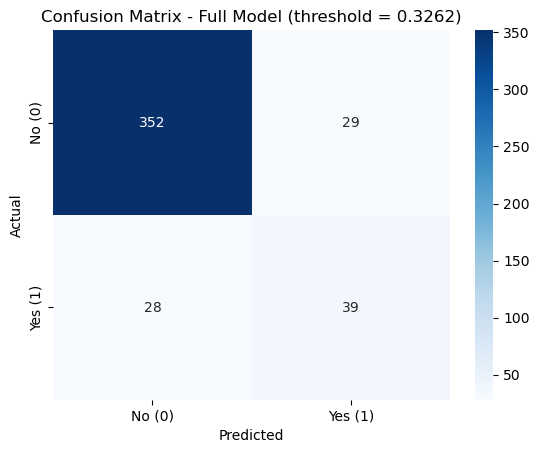

In [209]:
cm_full = confusion_matrix(y_test, y_pred_full)

sns.heatmap(cm_full, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No (0)', 'Yes (1)'],
            yticklabels=['No (0)', 'Yes (1)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - Full Model (threshold = {threshold_full:.4f})")
plt.show()

### 3.5. ROC Curve

We used the ROC curve for later to compare with the different models, as it measures the 
overall ability of the model to rank customers by their likelihood of responding.

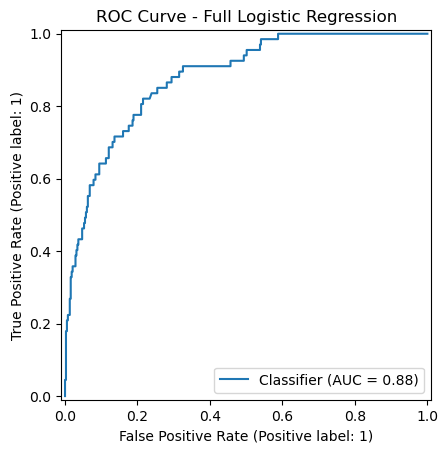

In [210]:
RocCurveDisplay.from_predictions(y_test, y_prob_full)
plt.title("ROC Curve - Full Logistic Regression")
plt.show()

### 3.6. Feature Importance
To understand which variables influence campaign response, we analyze the coefficients 
of the logistic regression model.

In [211]:
ohe_full = full_model.named_steps['preprocessor'].named_transformers_['cat']
cat_names_full = ohe_full.get_feature_names_out(categorical_features_full).tolist()
all_names_full = numerical_features_full + cat_names_full

coefs_full = full_model.named_steps['classifier'].coef_[0]

coef_df_full = pd.DataFrame({
    'Feature': all_names_full,
    'Coefficient': coefs_full,
    'Odds Ratio': np.exp(coefs_full)
}).sort_values(by='Coefficient', ascending=False)

n_zeroed = (coef_df_full['Coefficient'] == 0).sum()
print(f"Features retained by L1 : {len(coef_df_full) - n_zeroed} / {len(coef_df_full)}")
print(f"Features zeroed out: {n_zeroed}\n")

coef_df_full.round(4)

Features retained by L1 : 19 / 20
Features zeroed out: 1



,Feature,Coefficient,Odds Ratio
6,Total_Accepted_Campaigns,1.0814,2.9489
3,Customer_Tenure,0.9047,2.4711
14,Education_PhD,0.8673,2.3806
7,NumDealsPurchases,0.2559,1.2916
4,Total_Spending,0.2522,1.2868
13,Education_Master,0.2304,1.2591
1,Income,0.2237,1.2507
19,Marital_Status_Widow,0.2067,1.2296
8,NumWebVisitsMonth,0.1922,1.2119
12,Education_Graduation,0.1328,1.1420


### 3.7. Important Drivers Plot

To make the interpretation easier, we use vizualizations to learn the most influential positive and negative 
predictors of campaign response.

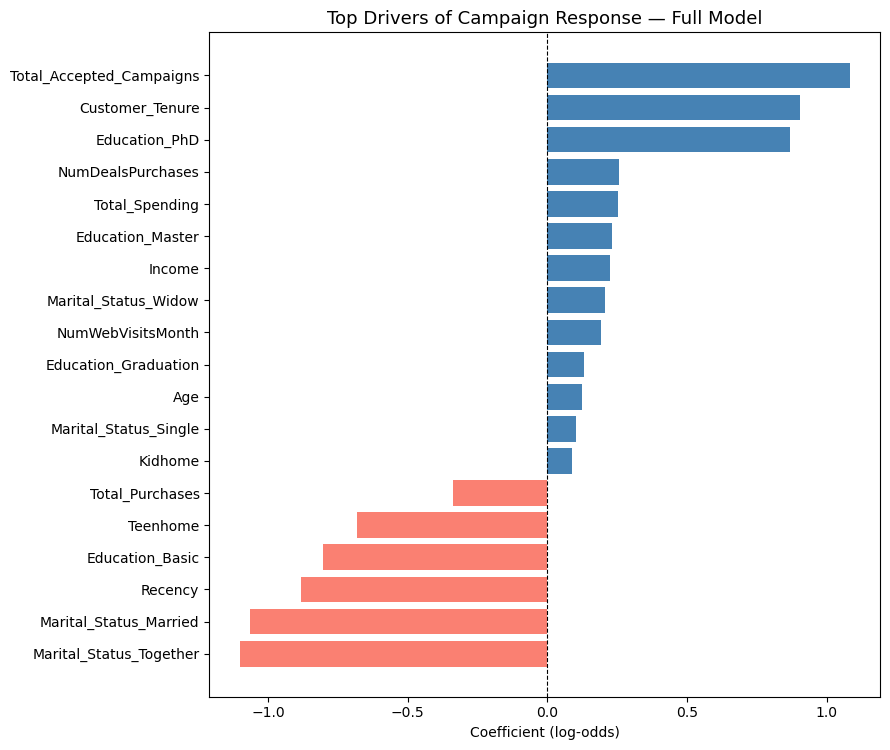

In [212]:
coef_df_full_nonzero = coef_df_full[coef_df_full['Coefficient'] != 0].copy()
coef_df_full_nonzero = coef_df_full_nonzero.sort_values('Coefficient', ascending=True)

colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df_full_nonzero['Coefficient']]
fig, ax = plt.subplots(figsize=(9, max(4, len(coef_df_full_nonzero) * 0.4)))
ax.barh(coef_df_full_nonzero['Feature'], coef_df_full_nonzero['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Top Drivers of Campaign Response — Full Model', fontsize=13)
ax.set_xlabel('Coefficient (log-odds)')
plt.tight_layout()
plt.show()


### 3.8. Interpretation of Full Model Results

The full logistic regression model provides a general view of which factors influence campaign response. It uses Elastic Net regularisation with an optimal l1_ratio of 0.3, indicating that the best penalty leans closer to L2 than L1.

he model achieves a **ROC-AUC** of 0.88 and an **F1** of 0.58 on the positive class, with the tuned threshold of 0.33 correctly identifying 39 out of 67 actual responders (**recall** of 58%) while maintaining a **precision** of 57% (meaning that roughly 1 in 2 customers flagged as likely responders would actually convert), a substantial improvement over the 15% baseline.

Amongst the positive indicators, past campaign acceptance is the best predictor (OR = 2.95), followed by `Customer_Tenure` (OR = 2.47) and `Education_PhD` (OR = 2.38), indicating that committed, highly educated consumers with a history of involvement in campaigns are the most responsive. `Total_Spending` (OR = 1.29), `Income` (OR = 1.25), and `Education_Master` (OR = 1.26) all indicate that higher-value, better educated clients react more frequently.

On the contrary, `Marital_Status_Together` (OR = 0.33) and `Marital_Status_Married` (OR = 0.35) are the most powerful deterring factors, followed by `recency` (OR = 0.41) and `Education_Basic` (OR = 0.45), which indicates that recently inactive customers in shared households with lower levels of education are significantly less likely to respond. `Teenhome` (OR = 0.51) and `Total_Purchases` (OR = 0.71) both lower response probability.

Only `Marital_Status_Other` was zeroed out by the Elastic Net penalty, confirming that the L2 component successfully retained most features rather than eliminating correlated ones arbitrarily as pure L1 would have done.

To isolate the contribution of behavioural and demographic signals separately, two targeted sub-models are estimated in the sections that follow, allowing us to evaluate whether campaign response is better explained by who the customer is or by how the customer behaves.

## 4. Behavioural Model (No Regularization)

To better understand the role of customer engagement and purchasing behaviour in campaign response, we estimate a logistic regression model using only behavioural variables.

The behavioural model is estimated without regularisation. Total_Accepted_Campaigns, Recency, and Total_Spending were among the highest correlates with Response in the bivariate analysis, meaning that feature selection is not a modelling concern. With approximately 1,800 training observations and only six predictors, the observations-to-features ratio is large enough to make overfitting unlikely. 

### 4.1. Preprocessing & Behavioural Logistic Regression

In [213]:
## Preprocessing Pipeline (Behavioral Model)
preprocessor_behav = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features_behav)
])

## Behavioral Logistic Regression (L1)
behav_model = Pipeline(steps=[
    ('preprocessor', preprocessor_behav),
    ('classifier', LogisticRegression(
        penalty=None,
        max_iter=1000,
        random_state=42
    ))
])

behav_model.fit(X_train_behav, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Recency', 'Total_Spending',
                                                   'Total_Purchases',
                                                   'Total_Accepted_Campaigns',
                                                   'NumDealsPurchases',
                                                   'NumWebVisitsMonth'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, penalty=None,
                                    random_state=42))])

### 4.2. Threshold Tuning

In [214]:
threshold_behav = find_best_threshold_oof(behav_model, X_train_behav, y_train)


Optimal threshold (F1): 0.1879
Best OOF F1:            0.5290


### 4.3. Model Evaluation

In [215]:
## Predictions
y_prob_behav = behav_model.predict_proba(X_test_behav)[:,1]
y_pred_behav = (y_prob_behav >= threshold_behav).astype(int)

## Metrics
accuracy_behav = accuracy_score(y_test, y_pred_behav)
precision_behav = precision_score(y_test, y_pred_behav)
recall_behav = recall_score(y_test, y_pred_behav)
f1_behav = f1_score(y_test, y_pred_behav)
auc_behav = roc_auc_score(y_test, y_prob_behav)

print("Accuracy:", accuracy_behav)
print("Precision:", precision_behav)
print("Recall:", recall_behav)
print("F1:", f1_behav)
print("ROC-AUC:", auc_behav)

Accuracy: 0.828125
Precision: 0.4418604651162791
Recall: 0.5671641791044776
F1: 0.49673202614379086
ROC-AUC: 0.8513730559799427


### 4.4 Confusion Matrix

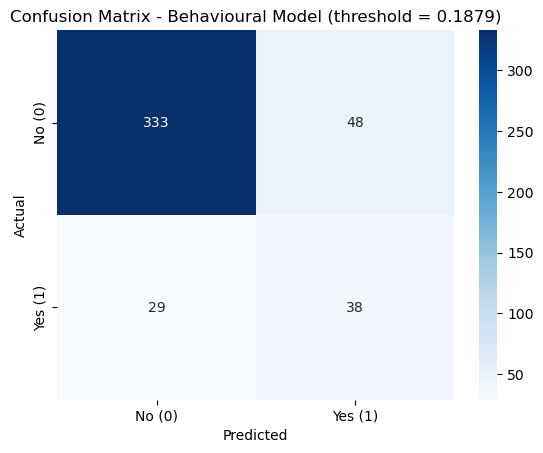

In [216]:
cm_behav = confusion_matrix(y_test, y_pred_behav)

sns.heatmap(cm_behav, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No (0)', 'Yes (1)'],
            yticklabels=['No (0)', 'Yes (1)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - Behavioural Model (threshold = {threshold_behav:.4f})")
plt.show()

### 4.5 ROC Curve

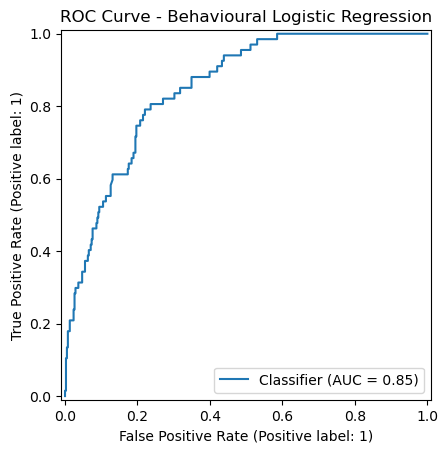

In [217]:
RocCurveDisplay.from_predictions(y_test, y_prob_behav)
plt.title("ROC Curve - Behavioural Logistic Regression")
plt.show()

### 4.6. Feature Importance

In [218]:
coefs_behav = behav_model.named_steps['classifier'].coef_[0]

coef_df_behav = pd.DataFrame({
    'Feature': numerical_features_behav,
    'Coefficient': coefs_behav,
    'Odds Ratio': np.exp(coefs_behav)
}).sort_values('Coefficient', ascending=False)

coef_df_behav.round(4)

,Feature,Coefficient,Odds Ratio
3,Total_Accepted_Campaigns,0.8368,2.3090
1,Total_Spending,0.7035,2.0209
5,NumWebVisitsMonth,0.4368,1.5478
4,NumDealsPurchases,0.0685,1.0710
2,Total_Purchases,-0.2689,0.7642
0,Recency,-0.7639,0.4659


### 4.7. Important Drivers Plot

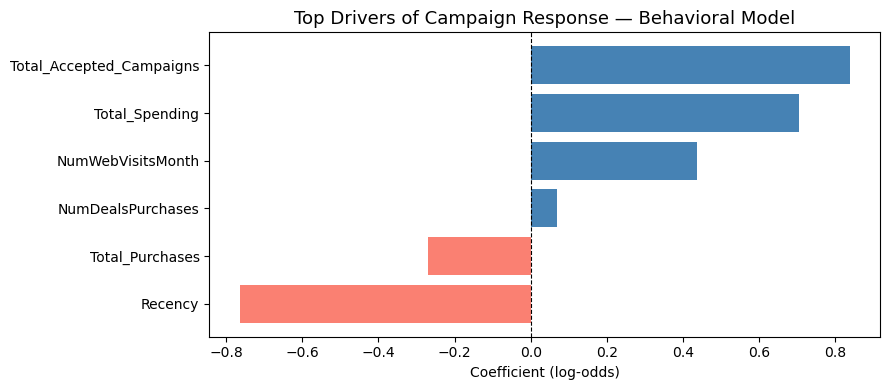

In [219]:
coef_df_behav_nonzero = coef_df_behav[coef_df_behav['Coefficient'] != 0].copy()
coef_df_behav_nonzero = coef_df_behav_nonzero.sort_values('Coefficient', ascending=True)

colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df_behav_nonzero['Coefficient']]
fig, ax = plt.subplots(figsize=(9, max(4, len(coef_df_behav_nonzero) * 0.4)))
ax.barh(coef_df_behav_nonzero['Feature'], coef_df_behav_nonzero['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Top Drivers of Campaign Response — Behavioral Model', fontsize=13)
ax.set_xlabel('Coefficient (log-odds)')
plt.tight_layout()
plt.show()



### 4.8. Interpretation of Behavioral Model Results

The behavioural model has a **ROC-AUC** of 0.85, indicating good overall discriminative ability with only six engagement variables. At the tuned threshold of 0.19, the model accurately detects 38 out of 67 actual respondents (**recall** of 57% and **precision** of 44%), implying that almost two out of every five consumers classified as possible responders will convert, a significant improvement over the 15% baseline.

Among the positive drivers, `Total_Accepted_Campaigns` is the strongest predictor (OR = 2.31), reinforcing that prior engagement is the clearest signal of future receptiveness. `Total_Spending` follows closely (OR = 2.02), confirming that higher-value customers are significantly more likely to respond.

`Recency` has the largest negative coefficient (OR = 0.47), supporting the EDA's result that consumers who purchased more recently are significantly more likely to react (every extra day since the last purchase lowers the chance of responding). Additionally, `Total_Purchases` has a negative coefficient (OR = 0.76), alongside a positive Total_Spending, indicating that customers who spend more on each transaction, instead of buying more frequently, are the most profitable targets for this campaign.

Surprisingly, **NumWebVisitsMonth** has a positive coefficient (OR = 1.55), which appears to contradict the EDA result of a near-zero difference across groups. This is likely a suppressor effect: once spending and recency are controlled for, frequent web visitors who still spend are a positive signal. Finally, `NumDealsPurchases` has a modest positive effect (OR = 1.07).



## 5. Demographic Model with L2 Regularization

The demographic model uses L2 regularisation. While the five numerical features are largely independent, the categorical variables Education and Marital_Status expand to approximately 14 columns after one-hot encoding, and several categories (particularly Widow and Other) contain very few observations. 

Without regularisation, coefficients on sparse categories can become inflated and unstable, driven by small sample artefacts rather than genuine signal. L2 penalisation shrinks these estimates toward zero, improving stability without eliminating any feature entirely. Feature selection is not the goal here, making L2 the appropriate choice over L1 or ElasticNet.


### 5.1. Preprocessing & Demographic Logistic Regression


In [220]:
## Preprocessing Pipeline (Demographic Model)
preprocessor_demo = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_demo),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features_demo)
    ]
)

## Demographic Logistic Regression (L1)
demo_model = Pipeline(steps=[
    ('preprocessor', preprocessor_demo),
    ('classifier', LogisticRegression(
        penalty='l2',
        solver='lbfgs',
        C=1.0,
        max_iter=1000,
        random_state=42
    ))
])

demo_model.fit(X_train_demo, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Income',
                                                   'Customer_Tenure', 'Kidhome',
                                                   'Teenhome']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Education',
                                                   'Marital_Status'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

### 5.2. Threshold Tuning

In [221]:
threshold_demo = find_best_threshold_oof(demo_model, X_train_demo, y_train)

Optimal threshold (F1): 0.1880
Best OOF F1:            0.4246


### 5.3. Model Evaluation


In [222]:
y_prob_demo = demo_model.predict_proba(X_test_demo)[:, 1]
y_pred_demo = (y_prob_demo >= threshold_demo).astype(int)

## Metrics
accuracy_demo = accuracy_score(y_test, y_pred_demo)
precision_demo = precision_score(y_test, y_pred_demo)
recall_demo = recall_score(y_test, y_pred_demo)
f1_demo = f1_score(y_test, y_pred_demo)
auc_demo = roc_auc_score(y_test, y_prob_demo)

print("Accuracy:", accuracy_demo)
print("Precision:", precision_demo)
print("Recall:", recall_demo)
print("F1:", f1_demo)
print("ROC-AUC:", auc_demo)

Accuracy: 0.7477678571428571
Precision: 0.3230769230769231
Recall: 0.6268656716417911
F1: 0.4263959390862944
ROC-AUC: 0.7673443804599052


### 5.4. Confusion Matrix


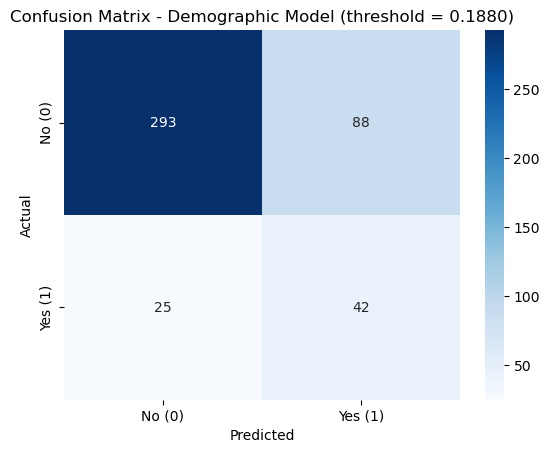

In [223]:
cm_demo = confusion_matrix(y_test, y_pred_demo)

sns.heatmap(cm_demo, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No (0)', 'Yes (1)'],
            yticklabels=['No (0)', 'Yes (1)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - Demographic Model (threshold = {threshold_demo:.4f})")
plt.show()

### 5.5. ROC Curve


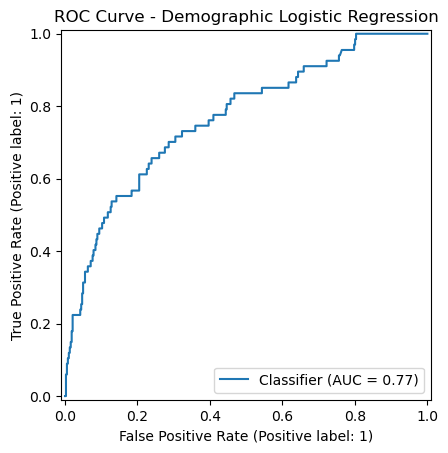

In [224]:
RocCurveDisplay.from_predictions(y_test, y_prob_demo)
plt.title("ROC Curve - Demographic Logistic Regression")
plt.show()

### 5.6. Feature Importance


In [230]:
ohe_demo = demo_model.named_steps['preprocessor'].named_transformers_['cat']
cat_names_demo = ohe_demo.get_feature_names_out(categorical_features_demo).tolist()
all_names_demo = numerical_features_demo + cat_names_demo

coefs_demo = demo_model.named_steps['classifier'].coef_[0]

coef_df_demo = pd.DataFrame({
    'Feature': all_names_demo,
    'Coefficient': coefs_demo,
    'Odds Ratio': np.exp(coefs_demo)
}).sort_values('Coefficient', ascending=False)

coef_df_demo.round(4)

,Feature,Coefficient,Odds Ratio
2,Customer_Tenure,0.7073,2.0286
8,Education_PhD,0.6575,1.9300
1,Income,0.4214,1.5241
13,Marital_Status_Widow,0.3844,1.4687
10,Marital_Status_Other,0.3100,1.3634
7,Education_Master,0.2407,1.2721
3,Kidhome,0.0569,1.0585
6,Education_Graduation,0.0472,1.0483
11,Marital_Status_Single,0.0016,1.0016
0,Age,-0.0086,0.9914


### 5.7. Important Drivers Plot


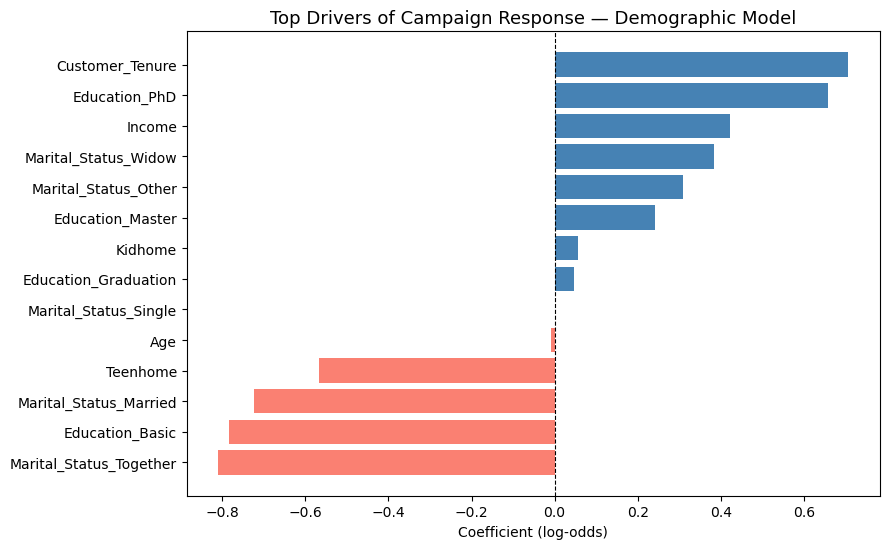

In [226]:
coef_df_demo_nonzero = coef_df_demo[coef_df_demo['Coefficient'] != 0].copy()
coef_df_demo_nonzero = coef_df_demo_nonzero.sort_values('Coefficient', ascending=True)

colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df_demo_nonzero['Coefficient']]
fig, ax = plt.subplots(figsize=(9, max(4, len(coef_df_demo_nonzero) * 0.4)))
ax.barh(coef_df_demo_nonzero['Feature'], coef_df_demo_nonzero['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Top Drivers of Campaign Response — Demographic Model', fontsize=13)
ax.set_xlabel('Coefficient (log-odds)')
plt.tight_layout()
plt.show()



### 5.8. Interpretation of Demographic and Household Model Results

The demographic model achieves a **ROC-AUC** of 0.77, indicating moderate discriminative ability, consistent with the EDA finding that demographic variables are inherently weaker predictors of campaign response than behavioural ones. The F1-optimal threshold was found at 0.19 through out-of-fold cross-validation — considerably lower than the default 0.50 — reflecting the model's limited confidence in assigning high probabilities to the minority class.

At this threshold, the model correctly identifies 42 out of 67 actual responders, achieving a **recall** of 63% on the positive class, the highest recall of the three models. **Precision** stands at 32%, meaning that out of 130 customers flagged as likely responders (42 true positives + 88 false positives), roughly 1 in 3 would actually convert. In practical terms, the company would need to contact approximately 3 customers to reach 1 true responder, still a meaningful improvement over untargeted outreach where the baseline conversion rate is only 15%.

The coefficient table confirms the demographic profile of a likely responder: `Customer_Tenure` (OR = 2.03) and `Education_PhD` (OR = 1.93) are the strongest positive predictors, followed by `Income` (OR = 1.52) and `Marital_Status_Widow` (OR = 1.47). `Marital_Status_Other` (OR = 1.36) and `Education_Master` (OR = 1.27) also contribute positively.

On the negative side, `Marital_Status_Together` (OR = 0.45) and `Marital_Status_Married` (OR = 0.49) are the strongest deterrents, followed by `Education_Basic` (OR = 0.46) and `Teenhome` (OR = 0.57), suggesting that customers in shared households with lower education and teenagers at home are significantly less receptive. 

`Age` and `Marital_Status_Single` carry near-zero coefficients, confirming they add no meaningful predictive signal once the remaining variables are accounted for.

Overall, the demographic model is best understood as a profiling tool rather than a precision targeting instrument. Its high recall makes it useful for broad identification of likely responders, but its low precision means it generates a substantial number of wasted contacts, making it most appropriate as a fallback when transaction history is unavailable.

## 6. Summary of Results

### 6.1. Metrics Table

In [231]:
results = {
    'Model': ['Full', 'Behavioural', 'Demographic'],
    'Threshold': [threshold_full, threshold_behav, threshold_demo],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_full),
        roc_auc_score(y_test, y_prob_behav),
        roc_auc_score(y_test, y_prob_demo)
    ],
    'Precision (1)': [
        precision_score(y_test, y_pred_full, zero_division=0),
        precision_score(y_test, y_pred_behav, zero_division=0),
        precision_score(y_test, y_pred_demo, zero_division=0)
    ],
    'Recall (1)': [
        recall_score(y_test, y_pred_full, zero_division=0),
        recall_score(y_test, y_pred_behav, zero_division=0),
        recall_score(y_test, y_pred_demo, zero_division=0)
    ],
    'F1 (1)': [
        f1_score(y_test, y_pred_full, zero_division=0),
        f1_score(y_test, y_pred_behav, zero_division=0),
        f1_score(y_test, y_pred_demo, zero_division=0)
    ],
}

results_df = pd.DataFrame(results).set_index('Model').round(3)

def highlight_best(s):
    is_best = s == s.max()
    return ['background-color: #a8d5a2; color: #155724; font-weight: bold'
            if v else '' for v in is_best]

results_df.style.apply(highlight_best, axis=0).format("{:.3f}")


,Threshold,ROC-AUC,Precision (1),Recall (1),F1 (1)
Model,,,,,
Full,0.326,0.880,0.574,0.582,0.578
Behavioural,0.188,0.851,0.442,0.567,0.497
Demographic,0.188,0.767,0.323,0.627,0.426


### 6.2. ROC Curves

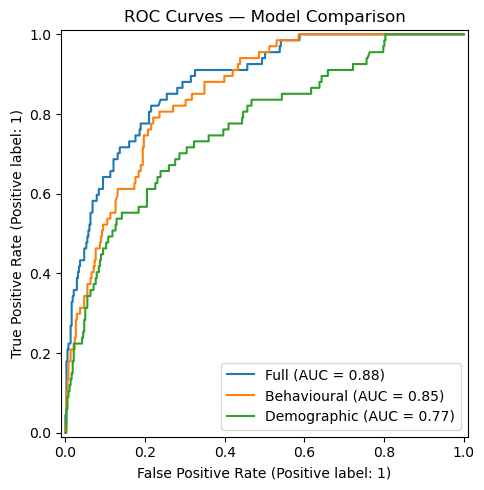

In [232]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_full, name="Full", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_behav, name="Behavioural", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_demo, name="Demographic", ax=ax)
ax.set_title("ROC Curves — Model Comparison")
plt.tight_layout()
plt.show()

### 6.3. Model Comparison

### 6.4. Recommended Model

## 7. Business Recommendations